In [1]:
# cargamos el modelo pre-entrenado
from tensorflow.keras.applications import VGG16

model = VGG16(weights='imagenet')
model.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# subimos el fichero/imagen
from google.colab import files
uploaded = files.upload()


Saving car_1.jpg to car_1.jpg


In [6]:
#procesamos la imagen
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

img_path = "car_1.jpg"

# Cargar imagen y redimensionar
img = image.load_img(img_path, target_size=(224, 224))

# Convertir a array
img_array = image.img_to_array(img)

# Añadir dimensión batch (1 imagen)
img_array = np.expand_dims(img_array, axis=0)

# Preprocesamiento para VGG16
img_array = preprocess_input(img_array)


In [7]:
# predecimos
from tensorflow.keras.applications.vgg16 import decode_predictions

preds = model.predict(img_array)

results = decode_predictions(preds, top=3)[0]

for r in results:
    print(r)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
('n06874185', 'traffic_light', np.float32(0.1673851))
('n02930766', 'cab', np.float32(0.13923055))
('n03791053', 'motor_scooter', np.float32(0.1191027))


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


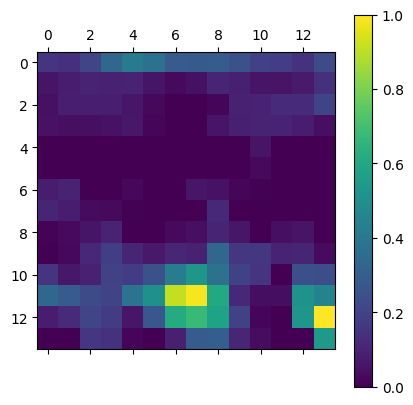

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Última capa convolucional
last_conv_layer = model.get_layer("block5_conv3")

# Crear un modelo parcial que vaya de la entrada hasta la última capa conv
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.output]
)

# Clase predicha
pred_class = np.argmax(preds[0])

# =======================================
# GradientTape
# =======================================
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    tape.watch(conv_outputs)
    loss = predictions[:, pred_class]

# Gradientes de la clase respecto a la salida conv
grads = tape.gradient(loss, conv_outputs)

# Promedio de los gradientes por canal
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiplicar cada canal por su importancia
conv_outputs = conv_outputs.numpy()[0]
for i in range(pooled_grads.shape[0]):
    conv_outputs[:, :, i] *= pooled_grads[i].numpy()

# Heatmap final
heatmap = np.mean(conv_outputs, axis=-1)
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Visualizar heatmap
plt.matshow(heatmap, cmap='viridis')
plt.colorbar()
plt.show()
# valores cercanos a 1 son canales importantes, en caso contrario no.


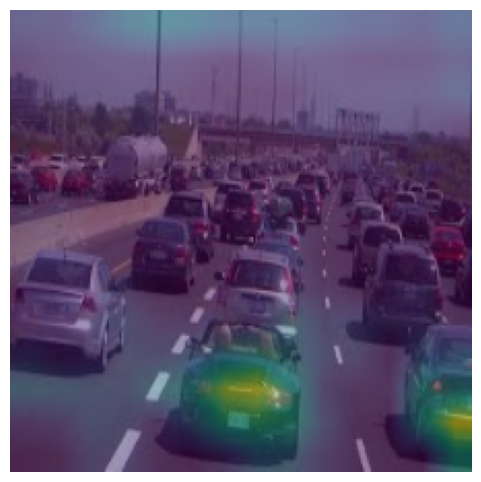

In [19]:
# superponemos la imagen
import cv2
import matplotlib.pyplot as plt

# heatmap ya normalizado entre 0 y 1
heatmap = np.uint8(255 * heatmap)  # escala a 0-255
heatmap = cv2.resize(heatmap, (224, 224))  # tamaño imagen original

# aplicar colormap (viridis)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_VIRIDIS)

# leer imagen original
img_original = cv2.imread("car_1.jpg")
img_original = cv2.resize(img_original, (224, 224))

# superponer heatmap con transparencia alpha
alpha = 0.5 # alpha mas elevado mas resalta el heatmap
overlayed_img = cv2.addWeighted(img_original, 1 - alpha, heatmap_color, alpha, 0)

# mostrar
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlayed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
